### This notebook computes "VCA3. Number of hydraulic and natural infrastrcture works for water storage and distribution " indicator for the 27 basins of IKI Project

Spanish: Número de obras de infraestructura hidráulica y natural para el almacenamiento y distribución del agua

**Created:** 11/10/2025 by Serena Gilson. Current contact: Sophia Bakar (sbakar@rti.org) 
 
**Inputs:** INEI report downloaded from http://censos1.inei.gob.pe/Cenagro/redatam/# (base de datos REDATAM - CENAGRO 201240, información sobre pequeñosreservorios/embalses de regulación estacional según el número de equipos a nivel distrital. Para ello, dirígete a la sección Condiciones de la actividad agropecuaria y selecciona Infraestructura.)
 
**Assumptions:** Assumes 2012 data to be "current" given it is the data we have. Using weighted method for assigning district-level data to COMIDs. 
 
**N/A Handling:** COMIDs with no hydraulic infrastructure are NaN.  

**Future work:**  Does not have the following information included: info de Agro Rural y UE Fondo Sierra Azul sobre las acciones de recarga
hídrica para siembra y cosecha de agua, es decir, diques para cochas, zanjas de infiltración,
reforestación, vegetación, entre otros.
 
**Notes:** 

We add in canales and bocotomas counts. 

General Methodology:  
1. Extracts the number of agricultural infrastructure equpment objects (numero equipos) per district from INEI data.  
2. Determines the proportionate area of each district within each COMID.  
3. Applies proportionate values to determine the number of agricultural infrastructure objects in each COMID.  
4. Performs spatial joins with hydraulic insfrastructure shapefiles (bocatomas, presas, and canals) to determine the total of each in each COMID.  
5. Sums all values (INEI, bocatomas, presas, and canals) for the total number of hydraulic infrastructure features per COMID.    

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [ ]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [ ]:
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
district_area = master_path / "Indicadores" / "COMID_District_Fractions.csv"
inei_infra = master_path / "Indicadores" / "Datos_INEI" / "INEI_reporte_VCA3.xlsx"
bocatomas_shp = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Bocatomas.shp"
canals_tras_shp = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "CanalTrasvase.shp"
canals_ad_shp = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "CanalAduccion.shp"
canals_der_shp = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "CanalDerivacion.shp"
canals_lat_shp = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "CanalLateral.shp"
presas_shp = master_path / "Indicadores" / "Datos_ANA" / "Presas.shp"


In [3]:
# set up indicator ID and get scenarios from database
IndID= 503 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
district_area_within_COMID= pd.read_csv(district_area)
infra = pd.read_excel(inei_infra)

subbasins_crs = subbasins_gdf.crs
bocatomas_gdf = gpd.read_file(bocatomas_shp).to_crs(subbasins_crs)
presas_gdf = gpd.read_file(presas_shp).to_crs(subbasins_crs)
canals_tras_gdf = gpd.read_file(canals_tras_shp).to_crs(subbasins_crs)
canals_lat_gdf = gpd.read_file(canals_lat_shp).to_crs(subbasins_crs)
canals_ad_gdf = gpd.read_file(canals_ad_shp).to_crs(subbasins_crs)
canals_der_gdf = gpd.read_file(canals_der_shp).to_crs(subbasins_crs)

In [6]:
# format the inei infrastructure dataframe
top_row_name= 'Infraestructura agropecuaria'

#remove empty rows 
infra = infra.dropna(axis=0, how='all')  # Drop rows that are completely NaN

#remove unnamed: 1 and and unnamed: 3 columns
infra = infra.drop(columns=['Unnamed: 1', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')

#Keep only rows with 'Pequeño reservorio / Embalse de regulación estacional' or 'AREA' in 'Infraestructura agropecuaria' column
infra = infra[infra[top_row_name].str.contains('Pequeño reservorio|AREA', case=False, na=False)]

#Replace 'Pequeño reservorio / Embalse de regulación estacional' with 'TOTAL' in 'Infraestructura agropecuaria' column
infra[top_row_name] = infra[top_row_name].str.replace('Pequeño reservorio / Embalse de regulación estacional', 'TOTAL', regex=False)

indices_to_drop = []

# Iterate through the rows to check for AREA rows and their corresponding Total rows
for i in range(len(infra) - 1):  # Stop at the second-to-last row to avoid index errors
    if 'AREA' in str(infra.iloc[i][top_row_name]).upper():  # Check if the current row is an AREA row
        next_row = infra.iloc[i + 1]
        if 'TOTAL' in str(next_row[top_row_name]).upper():  # Check if the next row is a Total row
            # Assign the value from the next row to the "Total Heads" column of the current row
            infra.at[infra.index[i], 'Total_Dist'] = next_row['Unnamed: 2']
            # Mark the Total row for dropping
            indices_to_drop.append(infra.index[i + 1])

# Drop all marked indices at once
infra.drop(index=indices_to_drop, inplace=True)

# Reset the index after dropping rows
infra.reset_index(drop=True, inplace=True)

# Convert Total_Dist to numeric, coercing errors to NaN, then fill NaN with 0 for summing
infra['Total_Dist'] = pd.to_numeric(infra['Total_Dist'], errors='coerce').fillna(0)

#remove all rows from Temas that are NA
infra = infra.dropna(subset=[top_row_name])

infra = infra.drop(columns=['Unnamed: 2'], errors='ignore')

# Extract IDDIST (district ID) from the top_row_name column# Drop the Unnamed: 2 column

# The format is "AREA # XXXXX" where XXXXX is the district ID
infra['IDDIST'] = infra[top_row_name].str.extract(r'AREA # (\d+)')[0]

In [7]:
#WEIGHTED METHOD FUNCTION 
# For each COMID, calculate proportionate lighting values based on district area fractions
#could amplify this fraction so it could read in any value by IDDIST 
def calculate_proportionate_values(district_fractions_df, value_df, column_name, comid_list):
    """
    Calculate proportionate values for each COMID based on district area fractions
    
    Parameters:
    - district_fractions_df: DataFrame with COMID, DISTRICT, district_area_within_COMID_fraction
    - value_df: DataFrame with IDDIST and indicator values
    - column_name: Name of the column containing the indicator values
    - comid_list: List of COMIDs to process
    
    Returns:
    - DataFrame with COMID and proportionate_indicator_value
    """
    # Ensure IDDIST and DISTRICT columns are in the same format
    value_df = value_df.copy()
    district_fractions_df = district_fractions_df.copy()
    
    value_df['IDDIST'] = value_df['IDDIST'].astype(str).str.strip()
    district_fractions_df['DISTRICT'] = district_fractions_df['DISTRICT'].astype(str).str.strip()
    
    results = []
    
    for comid in comid_list:
        # Get all districts within this COMID
        districts_in_comid = district_fractions_df[district_fractions_df['COMID'] == comid]
        
        total_proportionate_value = 0
        
        for _, row in districts_in_comid.iterrows():
            district_id = row['DISTRICT']
            fraction = row['district_area_within_COMID_fraction']
            # Get the indicator value for this district
            ind_value = value_df[value_df['IDDIST'] == district_id][column_name].values

            if len(ind_value) > 0:
                # Multiply district value by the fraction of area within COMID
                proportionate_value = ind_value[0] * fraction
                total_proportionate_value += proportionate_value
        
        results.append({
            'COMID': comid,
            'proportionate_indicator_value': total_proportionate_value
        })
    
    return pd.DataFrame(results)

In [8]:
# WEIGHTED METHOD: Calculate proportionate values based on district area fractions within each COMID

# Prepare district data for weighted method
infra_weighted = infra.copy()

# Get list of all COMIDs
comid_list = subbasins_gdf['COMID'].unique().tolist()

# Calculate proportionate values using weighted method
weighted_results = calculate_proportionate_values(
    district_fractions_df=district_area_within_COMID,
    value_df=infra_weighted,
    column_name='Total_Dist',
    comid_list=comid_list
)

# Merge weighted results back to subbasins
subbasins_gdf = subbasins_gdf.merge(
    weighted_results,
    on='COMID',
    how='left'
)

# Rename the proportionate value column for clarity
subbasins_gdf = subbasins_gdf.rename(columns={'proportionate_indicator_value': 'Total_Dist_Weighted'})

print(f"Weighted method applied. Total COMIDs: {len(subbasins_gdf)}")
print(f"\nSummary statistics for Total_Dist_Weighted:")
print(subbasins_gdf['Total_Dist_Weighted'].describe())

Weighted method applied. Total COMIDs: 3655

Summary statistics for Total_Dist_Weighted:
count    3655.000000
mean        1.979516
std        10.525681
min         0.000000
25%         0.000000
50%         0.000000
75%         0.523743
max       314.472893
Name: Total_Dist_Weighted, dtype: float64


In [9]:
# COUNT HYDRAULIC INFRASTRUCTURE AND DISTRIBUTION FEATURES PER COMID

# Perform spatial join to count features for each COMID
bocatomas_per_comid = gpd.sjoin(bocatomas_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                  how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='bocatomas_count')

presas_per_comid = gpd.sjoin(presas_gdf, subbasins_gdf[['COMID', 'geometry']], 
                               how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='presas_count')

canals_tras_per_comid = gpd.sjoin(canals_tras_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                    how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='canals_tras_count')

canals_lat_per_comid = gpd.sjoin(canals_lat_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                   how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='canals_lat_count')

canals_ad_per_comid = gpd.sjoin(canals_ad_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                  how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='canals_ad_count')

canals_der_per_comid = gpd.sjoin(canals_der_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                   how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='canals_der_count')

subbasins_gdf = subbasins_gdf.merge(bocatomas_per_comid, on='COMID', how='left').merge(presas_per_comid, on='COMID', how='left') \
    .merge(canals_tras_per_comid, on='COMID', how='left').merge(canals_lat_per_comid, on='COMID', how='left') \
    .merge(canals_ad_per_comid, on='COMID', how='left').merge(canals_der_per_comid, on='COMID', how='left')

infrastructure_columns = ['bocatomas_count','presas_count','canals_tras_count','canals_lat_count','canals_ad_count','canals_der_count']

subbasins_gdf[infrastructure_columns] = subbasins_gdf[infrastructure_columns].fillna(0)
subbasins_gdf['Total_Infrastructure_Count'] = subbasins_gdf[infrastructure_columns].sum(axis=1)

subbasins_gdf['Total_Dist_Weighted'] = subbasins_gdf['Total_Dist_Weighted'].fillna(0)
subbasins_gdf['Total_VCA3'] = (subbasins_gdf['Total_Dist_Weighted'] + subbasins_gdf['Total_Infrastructure_Count'])

subbasins_gdf['Total_VCA3'] = subbasins_gdf['Total_VCA3'].where(subbasins_gdf['Total_VCA3'].isna(), subbasins_gdf['Total_VCA3'].astype(int))

# EXPLICITLY convert 0s to NaN
subbasins_gdf[infrastructure_columns] = subbasins_gdf[infrastructure_columns].replace(0, np.nan)
subbasins_gdf[['Total_Infrastructure_Count','Total_VCA3']] = subbasins_gdf[['Total_Infrastructure_Count','Total_VCA3']].replace(0, np.nan)


print(f"\nTotal bocatomas: {subbasins_gdf['bocatomas_count'].sum(skipna=True)}")
print(f"Total presas: {subbasins_gdf['presas_count'].sum(skipna=True)}")
print(f"Total canals: {subbasins_gdf[['canals_tras_count','canals_lat_count','canals_ad_count','canals_der_count']].sum(skipna=True).sum()}")
print("\nSummary statistics for Total_VCA3:")
print(subbasins_gdf['Total_VCA3'].describe())


Total bocatomas: 24684.0
Total presas: 49.0
Total canals: 56029.0

Summary statistics for Total_VCA3:
count    1994.000000
mean       43.824975
std        87.251147
min         1.000000
25%         5.000000
50%        16.000000
75%        47.000000
max      1385.000000
Name: Total_VCA3, dtype: float64


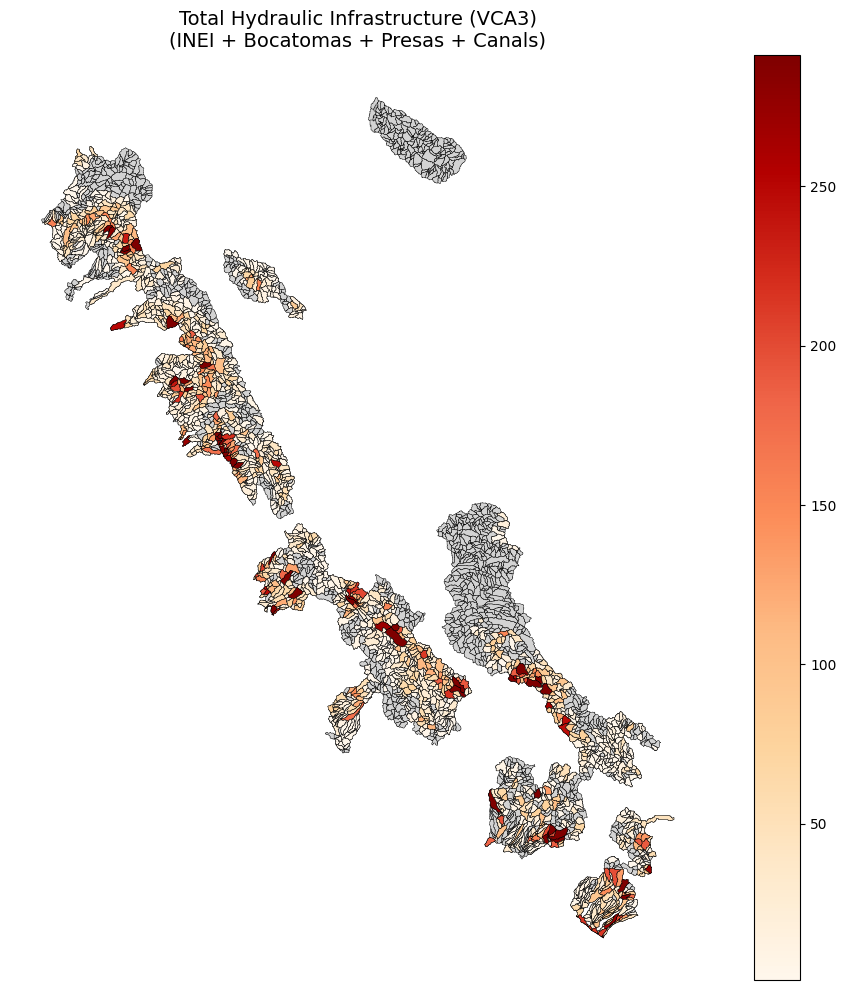

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot NaNs in light grey
subbasins_gdf.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.3)

# Plot valid values with scaled colorbar
data = subbasins_gdf[subbasins_gdf['Total_VCA3'].notna()]

if not data.empty:
    vmin = data['Total_VCA3'].quantile(0.02)
    vmax = data['Total_VCA3'].quantile(0.98)

    data.plot(
        column='Total_VCA3',
        cmap='OrRd',
        legend=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        edgecolor='black',
        linewidth=0.3
    )

ax.set_title(
    'Total Hydraulic Infrastructure (VCA3)\n'
    '(INEI + Bocatomas + Presas + Canals)',
    fontsize=14
)
ax.axis('off')

plt.tight_layout()
plt.show()


SQLITE INSERT 

In [11]:
# insert results into the database 
insert_data= subbasins_gdf 
value_column= 'Total_VCA3' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [12]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['Total_VCA3']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 503  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index  Total_VCA3
0    min         1.0
1    max      1385.0
2  count      1994.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [13]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()